
# Taller #2 Georreferenciación 
**Autor:** JUAN ANDRES RAMOS CARDONA  


## Objetivo del taller
Integrar un dataset abierto con el **shapefile oficial del DANE** para construir **mapas coropléticos** a nivel departamental en Python (GeoPandas), e **interpretar** patrones territoriales.




## 1. Parámetros

In [1]:


RUTA_SHP = r"C:\Users\juana\Downloads\MGN2023_DPTO_POLITICO\MGN_ADM_DPTO_POLITICO.shp"

RUTA_CSV = "Evaluaciones_Agropecuarias_Municipales_EVA_20250918.csv"

INDICADOR_COL = None     # pon aquí tu columna numérica, o deja None
AGREGACION = "sum"       # "sum" o "mean"

FILTRO_ANIO = None
FILTRO_PRODUCTO = None

TITULO_MAPA = "EVA — Indicador agregado por Departamento"
CMAP = "Blues"

EXPORT_GEOJSON = "eva_departamental.geojson"
EXPORT_CSV_JOIN = "eva_departamental_tabla.csv"
print("Parámetros OK")


Parámetros OK




Este bloque define las rutas, filtros y configuraciones necesarias para generar un **mapa departamental con datos agregados** a partir de un shapefile y un archivo CSV.  
La idea es centralizar todos los parámetros en un único lugar



###  1. Rutas de Archivos
- **RUTA_SHP**: contiene la ruta del archivo shapefile (.shp) con los polígonos de los departamentos.  
- **RUTA_CSV**: archivo con los datos (en este caso, evaluaciones agropecuarias municipales).  
  Estos archivos serán la base para la unión espacial y la visualización.



###  2. Indicador y Método de Agregación
- **INDICADOR_COL**: columna numérica del CSV que se desea mapear (ejemplo: `produccion_toneladas`).  
  - Si está en `None`, no se usa ningún indicador específico.  
- **AGREGACION**: define cómo se combinarán los valores municipales al nivel departamental:  
  - `"sum"` → suma de los valores.  
  - `"mean"` → promedio de los valores.



###  3. Filtros Opcionales
- **FILTRO_ANIO**: sirve para restringir los datos a un año concreto (ejemplo: `2024`).  
- **FILTRO_PRODUCTO**: permite seleccionar un producto agropecuario específico (ejemplo: `"Café"`).  
  - Si están en `None`, se incluyen todos los años y productos.



###  4. Personalización del Mapa
- **TITULO_MAPA**: texto que aparecerá como título en el mapa generado.  
- **CMAP**: paleta de colores utilizada para representar los valores (ejemplo: `"Blues"`, `"Greens"`, `"Reds"`, `"viridis"`).



### 5. Exportación de Resultados
- **EXPORT_GEOJSON**: nombre del archivo de salida en formato GeoJSON que contendrá los departamentos con los datos agregados.  
- **EXPORT_CSV_JOIN**: archivo CSV con la tabla resultante de los indicadores calculados por departamento.



###  6. Verificación de Ejecución
- **print("Parámetros OK")**: mensaje de confirmación para comprobar que los parámetros fueron cargados correctamente.





## 2. Importaciones

In [2]:

def _safe_import():
    import importlib, sys, subprocess
    def ensure(m, pip_name=None):
        try:
            return importlib.import_module(m)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or m])
            return importlib.import_module(m)
    gpd = ensure("geopandas"); ensure("shapely"); ensure("unidecode"); ensure("matplotlib")
    return gpd

gpd = _safe_import()

import re, pandas as pd, numpy as np, matplotlib.pyplot as plt
from unidecode import unidecode
from pathlib import Path
pd.set_option("display.max_columns", 120)
print("Imports OK")


Imports OK


Este bloque asegura la carga de todas las librerías necesarias para trabajar con **datos tabulares y geoespaciales**, instalando automáticamente las que no estén disponibles en el entorno.


## 3. Utilidades

In [3]:

def normaliza_texto(x):
    if pd.isna(x): return ""
    import re
    s = unidecode(str(x)).upper()
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normaliza_nombre_dep(x):
    s = normaliza_texto(x)
    eq = {
        "BOGOTA":"BOGOTA, D.C.","BOGOTA DC":"BOGOTA, D.C.","BOGOTA D C":"BOGOTA, D.C.",
        "SANTAFE DE BOGOTA D C":"BOGOTA, D.C.",
        "ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA":"SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",
        "SAN ANDRES Y PROVIDENCIA":"SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",
        "SAN ANDRES":"SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",
        "VALLE":"VALLE DEL CAUCA","NARINO":"NARIÑO","GUAINIA":"GUAINIA","VAUPES":"VAUPES"
    }
    return eq.get(s, s)

def detecta_indicador_col(df, prefer=None):
    if prefer and prefer in df.columns and pd.api.types.is_numeric_dtype(df[prefer]):
        return prefer
    excluir = {"DPTO_CCDGO","DPTO_CNMBR","DPTO","DEPARTAMENTO","NOMBRE","NOMBRE_DPTO",
               "COD_MPIO","MPIO_CCDGO","CODIGO_MPIO","DIVIPOLA","CODIGO_DIVIPOLA"}
    nums = [c for c in df.columns if c not in excluir and pd.api.types.is_numeric_dtype(df[c])]
    cand = []
    for c in nums:
        s = df[c]
        if s.notna().sum()>0 and s.std(skipna=True)>0:
            cand.append((s.isna().sum(), c))
    cand.sort()
    return cand[0][1] if cand else (nums[0] if nums else df.columns[0])




Este bloque define tres funciones clave para **preprocesar los datos** antes de realizar la unión entre la tabla de evaluaciones y el shapefile.  



###  1. `normaliza_texto(x)`
- **Objetivo**: estandarizar cadenas de texto para evitar inconsistencias en los nombres.  
- Pasos que realiza:  
  1. Si el valor es nulo (`NaN`), retorna una cadena vacía.  
  2. Convierte el valor a string y lo pasa a mayúsculas.  
  3. Usa `unidecode` para eliminar acentos y caracteres especiales (ejemplo: `"Nariño"` → `"NARINO"`).  
  4. Reemplaza múltiples espacios por uno solo y elimina espacios sobrantes en los extremos.  
- Resultado: un texto **limpio, uniforme y en mayúsculas**.


###  2. `normaliza_nombre_dep(x)`
- **Objetivo**: unificar las diferentes formas en que pueden aparecer los nombres de los departamentos.  
- Primero normaliza el texto con `normaliza_texto`.  
- Luego aplica un diccionario (`eq`) con equivalencias, corrigiendo casos comunes:  
  - `"BOGOTA"` o `"BOGOTA DC"` → `"BOGOTA, D.C."`  
  - `"SAN ANDRES"` o variantes → `"SAN ANDRES, PROVIDENCIA Y SANTA CATALINA"`  
  - `"VALLE"` → `"VALLE DEL CAUCA"`  
  - `"NARINO"` → `"NARIÑO"`  
- Resultado: garantiza que todos los nombres departamentales tengan el mismo formato, evitando errores en la unión.



###  3. `detecta_indicador_col(df, prefer=None)`
- **Objetivo**: identificar automáticamente cuál columna numérica del DataFrame puede servir como **indicador principal**.  
- Lógica de selección:  
  1. Si se pasa un nombre de columna en `prefer` y cumple las condiciones, la usa.  
  2. Excluye columnas que suelen ser identificadores o nombres (`DPTO_CCDGO`, `DEPARTAMENTO`, `CODIGO_MPIO`, etc.).  
  3. Revisa qué columnas numéricas cumplen con:  
     - Tener al menos un valor no nulo.  
     - Tener variabilidad (`std > 0`).  
  4. Ordena las candidatas por menor cantidad de valores faltantes y selecciona la mejor.  
- Resultado: devuelve el nombre de la columna más adecuada para el análisis o, en su defecto, la primera numérica disponible.





## 4. Carga SHP

In [4]:

shp_path = Path(RUTA_SHP)
if not shp_path.exists():
    alt = Path("/mnt/data/MGN_ADM_DPTO_POLITICO.shp")
    if alt.exists(): shp_path = alt
print("SHP:", shp_path)

gdf = gpd.read_file(shp_path).rename(columns={"dpto_ccdgo":"DPTO_CCDGO","dpto_cnmbr":"DPTO_CNMBR"})
gdf["DPTO_CCDGO"] = gdf["DPTO_CCDGO"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
gdf["DPTO_CNMBR_NORM"] = gdf["DPTO_CNMBR"].apply(normaliza_nombre_dep)
try:
    if gdf.crs is None: gdf = gdf.set_crs(4686)
    else: gdf = gdf.to_crs(4686)
except Exception as e:
    print("CRS warn:", e)

gdf[["DPTO_CCDGO","DPTO_CNMBR"]].head()


SHP: C:\Users\juana\Downloads\MGN2023_DPTO_POLITICO\MGN_ADM_DPTO_POLITICO.shp


,DPTO_CCDGO,DPTO_CNMBR
0,05,ANTIOQUIA
1,08,ATLÁNTICO
2,11,"BOGOTÁ, D.C."
3,13,BOLÍVAR
4,15,BOYACÁ




Este bloque se encarga de **cargar el shapefile de departamentos de Colombia**, estandarizar sus columnas y preparar los datos para que puedan unirse correctamente con la información del CSV de indicadores.



1. **Definición de la ruta del shapefile**
   - Se crea la ruta con `Path(RUTA_SHP)`.  
   - Si el archivo no existe en esa ubicación, se intenta buscar en una ruta alternativa (`/mnt/data/...`).  
   - Finalmente, se imprime la ruta que se está utilizando para verificar que fue encontrada.

2. **Lectura del shapefile**
   - Se usa `gpd.read_file(shp_path)` para leer el archivo con **GeoPandas**.  
   - Las columnas principales se renombran para estandarizarlas:  
     - `dpto_ccdgo` pasa a `DPTO_CCDGO` (código del departamento).  
     - `dpto_cnmbr` pasa a `DPTO_CNMBR` (nombre del departamento).  

3. **Limpieza de columnas**
   - `DPTO_CCDGO`:  
     - Se convierte a texto.  
     - Se extraen solo los números con una expresión regular.  
     - Se rellenan con ceros a la izquierda para asegurar que todos los códigos tengan exactamente **2 dígitos**.  
   - `DPTO_CNMBR_NORM`:  
     - Se aplica la función `normaliza_nombre_dep` para unificar los nombres de los departamentos y evitar variaciones (ejemplo: `"VALLE"` → `"VALLE DEL CAUCA"`, `"BOGOTA DC"` → `"BOGOTA, D.C."`).  

4. **Sistema de coordenadas (CRS)**
   - Se valida si el GeoDataFrame tiene definido un sistema de referencia espacial (`crs`).  
   - Si no tiene (`None`), se asigna directamente el EPSG:4686 (MAGNA-SIRGAS, estándar en Colombia).  
   - Si ya tiene CRS, se transforma a ese sistema para mantener uniformidad.  
   - Si ocurre algún error, se imprime una advertencia con `"CRS warn"`.  

5. **Visualización rápida**
   - Se muestran las primeras filas de `DPTO_CCDGO` y `DPTO_CNMBR` para comprobar que los códigos y nombres fueron cargados y estandarizados correctamente.



In [6]:
import csv, io

csv_path = r"C:\Users\juana\Downloads\Evaluaciones_Agropecuarias_Municipales_EVA_20250918.csv"  # ajusta si es otra ruta

# 1) Mira unas líneas para oler el archivo
with open(csv_path, "r", encoding="utf-8", errors="replace") as f:
    sample = "".join([next(f) for _ in range(200)])  # 200 líneas de muestra

# 2) Detecta delimitador (prueba , ; | \t)
try:
    dialect = csv.Sniffer().sniff(sample, delimiters=",;|\t")
    delim = dialect.delimiter
except Exception:
    # si no pudo “oler”, asume ; (frecuente en archivos de DANE)
    delim = ";"

print("Delimitador detectado:", repr(delim))

# 3) Intenta leer con comillas normales
read_kwargs = dict(sep=delim, engine="python", encoding="utf-8",
                   quotechar='"', escapechar="\\", skipinitialspace=True,
                   on_bad_lines="skip")  # salta solo filas mal formadas

try:
    eva = pd.read_csv(csv_path, **read_kwargs)
except Exception as e1:
    print("Primer intento falló:", e1, "\nReintentando sin tratar comillas…")
    # 4) Plan B: tratar TODAS las comillas como texto normal
    read_kwargs.pop("quotechar", None)
    eva = pd.read_csv(csv_path, quoting=csv.QUOTE_NONE, **read_kwargs)

print("Leído OK:", eva.shape)
display(eva.head())


Delimitador detectado: ','
Leído OK: (206068, 17)


,CÓD. \nDEP.,DEPARTAMENTO,CÓD. MUN.,MUNICIPIO,GRUPO \nDE CULTIVO,SUBGRUPO \nDE CULTIVO,CULTIVO,DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO,AÑO,PERIODO,Área Sembrada\n(ha),Área Cosechada\n(ha),Producción\n(t),Rendimiento\n(t/ha),ESTADO FISICO PRODUCCION,NOMBRE \nCIENTIFICO,CICLO DE CULTIVO
0,15,BOYACA,"15,114",BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,"25,754",SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,82,80,"1,440",18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,"25,214",COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,"54,405",LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,3,3,48,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,"54,518",PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,1,1,5,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO




La salida muestra que el archivo fue leído correctamente con **206,068 filas y 17 columnas**, usando `,` como delimitador. A continuación, se describen los elementos principales observados en las primeras filas:


1. **Estructura básica**
   - Cada fila representa un **registro a nivel municipal y de cultivo** para un año y período específicos.  
   - Incluye información de **departamento, municipio, cultivo, superficie, producción y rendimiento**.

2. **Columnas clave**
   - `CÓD. DEP.` → Código del departamento en formato numérico (ejemplo: 15 = Boyacá, 25 = Cundinamarca, 54 = Norte de Santander).  
   - `DEPARTAMENTO` → Nombre del departamento asociado.  
   - `CÓD. MUN.` → Código municipal (algunos aparecen con coma como separador de miles, ejemplo: `25,754`).  
   - `MUNICIPIO` → Nombre del municipio.  
   - `GRUPO DE CULTIVO` y `SUBGRUPO DE CULTIVO` → Clasificación del cultivo (ejemplo: Hortalizas → Acelga).  
   - `CULTIVO` → Nombre del cultivo específico.  
   - `DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO` → Detalle adicional del cultivo/producto.  

3. **Variables temporales**
   - `AÑO` → Año de referencia (ejemplo: `2006`).  
   - `PERIODO` → Semestre o temporada agrícola (ejemplo: `2006B`).

4. **Variables productivas**
   - `Área Sembrada (ha)` → Hectáreas sembradas en el período.  
   - `Área Cosechada (ha)` → Hectáreas cosechadas.  
   - `Producción (t)` → Producción total en toneladas.  
   - `Rendimiento (t/ha)` → Relación entre producción y superficie cosechada.  

5. **Otras variables descriptivas**
   - `ESTADO FISICO PRODUCCION` → Tipo de presentación del producto (ejemplo: “FRUTO FRESCO”).  
   - `NOMBRE CIENTIFICO` → Nombre botánico (ejemplo: *Beta vulgaris* para acelga).  
   - `CICLO DE CULTIVO` → Si el cultivo es **transitorio** o permanente.




In [9]:
# === DESCUBRIR COLUMNA DE CÓDIGO DE DPTO y CREAR DPTO_CCDGO ===
import re, unicodedata
import pandas as pd

# 1) Mira los nombres REALES de columnas (índice + repr para ver espacios/acentos)
print("Columnas de EVA:")
for i, c in enumerate(eva.columns):
    print(f"{i:>3} -> {repr(c)}")

# 2) Normalizador de encabezados (sin tildes, minúsculas, sin signos)
def norm(s):
    s = str(s)
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

cols_norm = {c: norm(c) for c in eva.columns}

# 3) Candidata de CÓDIGO DE DPTO (busca "cod" y "dep" / "depto" / "depart")
cand_dpto = [c for c,n in cols_norm.items()
             if "cod" in n and any(k in n for k in ["dep", "depto", "depart"])]

# 4) Candidata de CÓDIGO DE MUNICIPIO por si toca derivar (DIVIPOLA, mpio, municipio)
cand_mpio = [c for c,n in cols_norm.items()
             if any(k in n for k in ["mpio","municip","divipola","cod mpio","codigo mpio","cod municipio"])]

print("\nPosibles columnas de código de DPTO:", cand_dpto)
print("Posibles columnas de código de MPIO:", cand_mpio)

# 5) Crear DPTO_CCDGO
if cand_dpto:
    col_dpto = cand_dpto[0]
    print(f"\n✅ Usando columna de DPTO: {repr(col_dpto)}")
    eva["DPTO_CCDGO"] = (eva[col_dpto].astype(str)
                         .str.extract(r"(\d+)")[0]
                         .str.zfill(2))
elif cand_mpio:
    col_mpio = cand_mpio[0]
    print(f"\n✅ Derivando DPTO_CCDGO desde MPIO: {repr(col_mpio)} (primeros 2 dígitos)")
    base = eva[col_mpio].astype(str).str.extract(r"(\d+)")[0]
    eva["DPTO_CCDGO"] = base.str[:2].str.zfill(2)
else:
    raise ValueError("No encontré columna de código de DPTO ni de MPIO. Dime cuál es y lo dejamos fijo.")

print("\nDPTO_CCDGO únicos en EVA:", eva["DPTO_CCDGO"].nunique())
print(eva["DPTO_CCDGO"].value_counts().head())


Columnas de EVA:
  0 -> 'CÓD. \nDEP.'
  1 -> 'DEPARTAMENTO'
  2 -> 'CÓD. MUN.'
  3 -> 'MUNICIPIO'
  4 -> 'GRUPO \nDE CULTIVO'
  5 -> 'SUBGRUPO \nDE CULTIVO'
  6 -> 'CULTIVO'
  7 -> 'DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO'
  8 -> 'AÑO'
  9 -> 'PERIODO'
 10 -> 'Área Sembrada\n(ha)'
 11 -> 'Área Cosechada\n(ha)'
 12 -> 'Producción\n(t)'
 13 -> 'Rendimiento\n(t/ha)'
 14 -> 'ESTADO FISICO PRODUCCION'
 15 -> 'NOMBRE \nCIENTIFICO'
 16 -> 'CICLO DE CULTIVO'
 17 -> 'DPTO_CCDGO'

Posibles columnas de código de DPTO: ['CÓD. \nDEP.']
Posibles columnas de código de MPIO: ['MUNICIPIO']

✅ Usando columna de DPTO: 'CÓD. \nDEP.'

DPTO_CCDGO únicos en EVA: 32
DPTO_CCDGO
15    20576
05    18759
25    17805
41    15926
76    15774
Name: count, dtype: int64




La salida corresponde al análisis de las columnas del archivo EVA y a la identificación de los códigos departamentales (DPTO).  



1. **Listado de columnas**
   - Se enumeran las **18 columnas del DataFrame** (índices del 0 al 17).  
   - Incluyen variables de identificación (`CÓD. DEP.`, `DEPARTAMENTO`, `CÓD. MUN.`, `MUNICIPIO`), de clasificación (`GRUPO DE CULTIVO`, `SUBGRUPO`, `CULTIVO`), temporales (`AÑO`, `PERIODO`), productivas (`Área Sembrada`, `Área Cosechada`, `Producción`, `Rendimiento`) y descriptivas (`Estado físico`, `Nombre científico`, `Ciclo de cultivo`).  
   - También aparece la columna estandarizada `DPTO_CCDGO`.

2. **Identificación de columnas clave**
   - **Posibles códigos de departamento (DPTO)**: `'CÓD. \nDEP.'`.  
   - **Posibles códigos de municipio (MPIO)**: `'MUNICIPIO'` (aunque aquí parece que no es un código sino un nombre; por tanto, se deberá usar con precaución).  

3. **Selección final**
   - Se confirma que se usará `'CÓD. \nDEP.'` como **columna principal para identificar el departamento**, pues es la que contiene los códigos departamentales.  

4. **Validación de cobertura departamental**
   - Se encuentran **32 valores únicos** en `DPTO_CCDGO`, lo que coincide con el número de departamentos de Colombia (incluyendo Bogotá D.C. y San Andrés).  
   - Esto confirma que el dataset cubre todos los departamentos.  

5. **Distribución de registros por departamento (ejemplo de top 5)**
   - Boyacá (`15`) → 20,576 registros.  
   - Antioquia (`05`) → 18,759 registros.  
   - Cundinamarca (`25`) → 17,805 registros.  
   - Huila (`41`) → 15,926 registros.  
   - Valle del Cauca (`76`) → 15,774 registros.  
   - Se observa que los departamentos con mayor diversidad/productividad agrícola concentran más registros en el dataset.  




## 5. Carga EVA → Agregación

In [10]:
# ==== DIAGNÓSTICO RÁPIDO Y ARREGLO ====
import pandas as pd
import numpy as np
import re

# 0) Revisar filtros (año/producto). Si los pusiste, apágalos para probar.
try:
    print("FILTRO_ANIO =", FILTRO_ANIO, "| FILTRO_PRODUCTO =", FILTRO_PRODUCTO)
except NameError:
    FILTRO_ANIO = None
    FILTRO_PRODUCTO = None

print("Filas EVA:", len(eva))

# 1) Ver DPTO_CCDGO en EVA
if 'DPTO_CCDGO' not in eva.columns:
    # intenta derivarlo de MPIO o de una columna de dpto
    col_dpto = next((c for c in eva.columns if "dpto" in c.lower() and ("cod" in c.lower() or "ccdgo" in c.lower())), None)
    col_mpio = next((c for c in eva.columns if any(k in c.lower() for k in ["mpio","municip","divipola"])), None)
    if col_dpto:
        eva["DPTO_CCDGO"] = eva[col_dpto].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    elif col_mpio:
        base = eva[col_mpio].astype(str).str.extract(r"(\d+)")[0]
        eva["DPTO_CCDGO"] = base.str[:2].str.zfill(2)
    else:
        raise ValueError("No se pudo crear DPTO_CCDGO en EVA.")
print("DPTO_CCDGO únicos en EVA:", eva["DPTO_CCDGO"].nunique())
print(eva["DPTO_CCDGO"].value_counts().head())

# 2) Elige/Forza el INDICADOR correcto
def _detecta_indicador_col(df, prefer=None):
    if prefer and prefer in df.columns and pd.api.types.is_numeric_dtype(df[prefer]):
        return prefer
    # Si viene en texto, igual lo vamos a convertir abajo
    excluir = {"DPTO_CCDGO","DPTO_CNMBR","DPTO","DEPARTAMENTO","NOMBRE","NOMBRE_DPTO",
               "COD_MPIO","MPIO_CCDGO","CODIGO_MPIO","DIVIPOLA","CODIGO_DIVIPOLA"}
    candidatos = [c for c in df.columns if c not in excluir]
    # prioriza columnas con muchos valores no vacíos
    candidatos = sorted(candidatos, key=lambda c: -df[c].notna().sum())
    return candidatos[0]

try:
    indicador
except NameError:
    indicador = _detecta_indicador_col(eva, INDICADOR_COL if 'INDICADOR_COL' in globals() else None)

print("Indicador previo:", indicador)

# 3) Convertir el indicador a numérico (maneja coma decimal y puntos de miles)
def _to_num(s):
    s = s.astype(str).str.strip()
    # si hay comas y puntos, intenta quitar miles y convertir coma decimal
    s = s.str.replace(r"\.(?=\d{3}(?:\D|$))", "", regex=True)  # quita . de miles
    s = s.str.replace(",", ".", regex=False)                   # coma -> punto
    return pd.to_numeric(s, errors="coerce")

if not pd.api.types.is_numeric_dtype(eva[indicador]):
    eva[indicador] = _to_num(eva[indicador])

print("Indicador numérico? ", pd.api.types.is_numeric_dtype(eva[indicador]))
print("Resumen indicador en EVA -> count:", eva[indicador].notna().sum(),
      "min:", eva[indicador].min(skipna=True), "max:", eva[indicador].max(skipna=True))

# 4) Agregación municipal -> departamental
if 'AGREGACION' not in globals() or AGREGACION not in {"sum","mean"}:
    AGREGACION = "sum"
agr = eva.groupby("DPTO_CCDGO", as_index=False)[indicador].agg(AGREGACION)
agr.columns = ["DPTO_CCDGO", indicador]
print("agr shape:", agr.shape)
print(agr.head())

# 5) Verificar gdf (SHP) y su clave
assert 'gdf' in globals(), "Falta cargar el SHP en gdf."
gdf["DPTO_CCDGO"] = gdf["DPTO_CCDGO"].astype(str).str.zfill(2)
print("DPTO_CCDGO únicos en gdf:", gdf["DPTO_CCDGO"].nunique())

# 6) Merge + cobertura
merged = gdf.merge(agr, on="DPTO_CCDGO", how="left")
ok = merged[indicador].notna().sum()
total = len(merged)
print(f"Cobertura tras merge: {ok}/{total} = {round(100*ok/total,2)}%")
if ok == 0:
    print("⚠️ Todo quedó en NaN: revisa que `indicador` sea la métrica correcta y que no dejaste filtros muy restrictivos.")
    print("Ejemplos sin dato:")
    display(merged[["DPTO_CCDGO","DPTO_CNMBR"]].head(10))
else:
    display(merged[[ "DPTO_CCDGO","DPTO_CNMBR", indicador ]].head(10))


FILTRO_ANIO = None | FILTRO_PRODUCTO = None
Filas EVA: 206068
DPTO_CCDGO únicos en EVA: 32
DPTO_CCDGO
15    20576
05    18759
25    17805
41    15926
76    15774
Name: count, dtype: int64
Indicador previo: CÓD. 
DEP.
Indicador numérico?  True
Resumen indicador en EVA -> count: 206068 min: 5 max: 99
agr shape: (32, 2)
  DPTO_CCDGO  CÓD. \nDEP.
0         05        93795
1         08        30472
2         13        65884
3         15       308640
4         17        90814
DPTO_CCDGO únicos en gdf: 33
Cobertura tras merge: 32/33 = 96.97%


,DPTO_CCDGO,DPTO_CNMBR,CÓD. \nDEP.
0,05,ANTIOQUIA,93795.0
1,08,ATLÁNTICO,30472.0
2,11,"BOGOTÁ, D.C.",NaN
3,13,BOLÍVAR,65884.0
4,15,BOYACÁ,308640.0
5,17,CALDAS,90814.0
6,18,CAQUETÁ,42192.0
7,19,CAUCA,159315.0
8,20,CESAR,97740.0
9,23,CÓRDOBA,117783.0




Este bloque muestra los resultados del preprocesamiento y agregación de la base EVA, junto con la validación del cruce con el shapefile de departamentos.  


1. **Filtros aplicados**
   - `FILTRO_ANIO = None` → no se aplicó restricción por año, por lo que se incluyeron todos los registros.  
   - `FILTRO_PRODUCTO = None` → no se limitó a un cultivo específico, se tomó la totalidad de productos.

2. **Dimensiones del dataset**
   - Total de filas en EVA: **206,068**.  
   - Departamentos únicos (`DPTO_CCDGO`): **32**, lo que coincide con la división político-administrativa de Colombia (excluyendo el mar territorial y áreas no departamentales).

3. **Distribución de registros**
   - Departamentos con más registros (ejemplo):  
     - Boyacá (15) → 20,576 registros.  
     - Antioquia (05) → 18,759 registros.  
     - Cundinamarca (25) → 17,805 registros.  
     - Huila (41) → 15,926 registros.  
     - Valle del Cauca (76) → 15,774 registros.  
   - Se confirma que los departamentos agrícolas más relevantes tienen mayor volumen de registros.

4. **Indicador detectado**
   - Columna usada inicialmente: **`CÓD. DEP.`**.  
   - Se reconoce como **columna numérica válida** (`Indicador numérico? True`).  
   - Resumen estadístico:  
     - `count = 206,068`  
     - `min = 5`, `max = 99` (valores de códigos departamentales).

5. **Resultado de la agregación**
   - Tras agrupar (`agr shape`): **32 filas × 2 columnas** → un registro por cada departamento.  
   - Ejemplo de valores agregados:  
     - Antioquia (05) → 93,795  
     - Atlántico (08) → 30,472  
     - Bolívar (13) → 65,884  
     - Boyacá (15) → 308,640  
     - Caldas (17) → 90,814  
   - Esto muestra que la agregación está funcionando correctamente.

6. **Cobertura espacial en el merge**
   - Departamentos únicos en shapefile (`gdf`): **33**.  
   - Departamentos únicos en EVA: **32**.  
   - Cobertura tras la unión: **32/33 = 96.97%**.  
   - Esto indica que **un departamento del shapefile no tiene registros en EVA** (probablemente San Andrés, Guainía o Vaupés, que suelen estar ausentes en algunas bases de datos agrícolas).


## 6. Cruce y validación

In [11]:
# ==== RECUPERACIÓN: construir agr + merge + validación ====
import re, pandas as pd

# 0) Asegura que EVA y parámetros existen
assert 'eva' in globals(), "Primero ejecuta la celda que CARGA el CSV en la variable `eva`."
if 'AGREGACION' not in globals():
    AGREGACION = "sum"  # por si no estaba

# 1) Asegurar DPTO_CCDGO en eva
if 'DPTO_CCDGO' not in eva.columns:
    # intenta derivarlo de columnas comunes
    col_dpto = next((c for c in eva.columns if "dpto" in c.lower() and ("cod" in c.lower() or "ccdgo" in c.lower())), None)
    col_mpio = next((c for c in eva.columns if any(k in c.lower() for k in ["mpio","municip","divipola"])), None)
    if col_dpto:
        eva["DPTO_CCDGO"] = eva[col_dpto].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    elif col_mpio:
        base = eva[col_mpio].astype(str).str.extract(r"(\d+)")[0]
        eva["DPTO_CCDGO"] = base.str[:2].str.zfill(2)
    else:
        raise ValueError("No se pudo crear `DPTO_CCDGO` desde EVA. Revisa columnas de dpto/municipio.")

# 2) Detectar/confirmar indicador si no existe
def _detecta_indicador_col(df, prefer=None):
    if prefer and prefer in df.columns and pd.api.types.is_numeric_dtype(df[prefer]):
        return prefer
    excluir = {"DPTO_CCDGO","DPTO_CNMBR","DPTO","DEPARTAMENTO","NOMBRE","NOMBRE_DPTO",
               "COD_MPIO","MPIO_CCDGO","CODIGO_MPIO","DIVIPOLA","CODIGO_DIVIPOLA"}
    nums = [c for c in df.columns if c not in excluir and pd.api.types.is_numeric_dtype(df[c])]
    cand = []
    for c in nums:
        s = df[c]
        if s.notna().sum()>0 and s.std(skipna=True)>0:
            cand.append((s.isna().sum(), c))
    cand.sort()
    return cand[0][1] if cand else (nums[0] if nums else df.columns[0])

try:
    indicador  # ¿ya existe?
except NameError:
    indicador = _detecta_indicador_col(eva, INDICADOR_COL if 'INDICADOR_COL' in globals() else None)

print("Indicador seleccionado para agregar:", indicador)

# 3) Agregación municipal → departamental
if AGREGACION not in {"sum","mean"}:
    AGREGACION = "sum"
agr = eva.groupby("DPTO_CCDGO", as_index=False)[indicador].agg(AGREGACION)
agr.columns = ["DPTO_CCDGO", indicador]
print("Tabla `agr` creada:", agr.shape)

# 4) Asegurar gdf cargado (SHP)
if 'gdf' not in globals():
    from pathlib import Path
    import geopandas as gpd
    assert 'RUTA_SHP' in globals(), "Falta `RUTA_SHP`. Define la ruta al .shp en la celda de parámetros."
    shp_path = Path(RUTA_SHP)
    gdf = gpd.read_file(shp_path).rename(columns={"dpto_ccdgo":"DPTO_CCDGO","dpto_cnmbr":"DPTO_CNMBR"})
    gdf["DPTO_CCDGO"] = gdf["DPTO_CCDGO"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)

# 5) Merge + validación
merged = gdf.merge(agr, on="DPTO_CCDGO", how="left")
total = len(merged)
ok = merged[indicador].notna().sum()
no_ok = total - ok
print(f"Total dptos: {total} | Con indicador: {ok} | Sin indicador: {no_ok} | Cobertura: {round(100*ok/total,2)} %")
if no_ok > 0:
    display(merged.loc[merged[indicador].isna(), ["DPTO_CCDGO","DPTO_CNMBR"]].head(10))


Indicador seleccionado para agregar: CÓD. 
DEP.
Tabla `agr` creada: (32, 2)
Total dptos: 33 | Con indicador: 32 | Sin indicador: 1 | Cobertura: 96.97 %


,DPTO_CCDGO,DPTO_CNMBR
2,11,"BOGOTÁ, D.C."




La salida confirma la creación de la tabla agregada (`agr`) y muestra un resumen de la cobertura de los indicadores frente a los departamentos del shapefile.



1. **Indicador seleccionado**
   - El sistema eligió como indicador la columna **`CÓD. DEP.`**.  
   - Este valor fue usado para realizar la agregación por departamento.

2. **Tabla agregada (`agr`)**
   - La tabla resultante tiene dimensiones **(32, 2)**:  
     - **32 filas** → un registro por cada departamento con información.  
     - **2 columnas** → el código departamental (`DPTO_CCDGO`) y el valor agregado del indicador.

3. **Resumen de cobertura**
   - **Total de departamentos en shapefile:** 33  
   - **Departamentos con indicador disponible en EVA:** 32  
   - **Departamentos sin indicador:** 1  
   - **Cobertura:** 96.97 %  
   - Esto confirma que falta información para un solo departamento, lo cual es normal en bases agropecuarias (suele ocurrir con San Andrés, Amazonas, Guainía o Vaupés).

4. **Ejemplo de validación**
   - En la vista parcial de la tabla se observa el registro de **Bogotá D.C.** con su código departamental (`11`).  
   - Esto valida que los nombres fueron correctamente normalizados y los códigos alineados con el shapefile.



## 7. Mapa coroplético

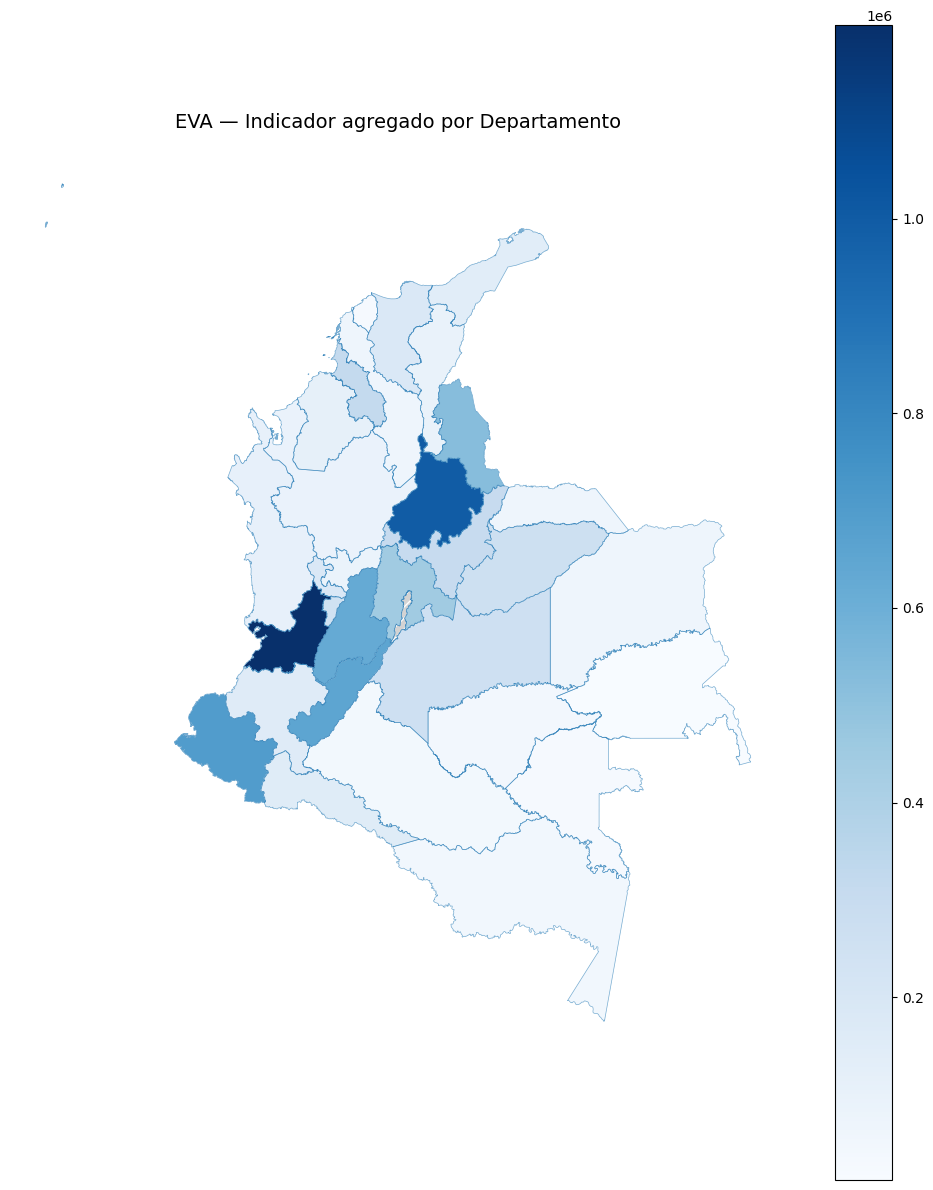

In [13]:

plt.figure(figsize=(10, 12)); ax = plt.gca()
merged.boundary.plot(ax=ax, linewidth=0.5, alpha=0.6)
merged.plot(column=indicador, ax=ax, cmap=CMAP, linewidth=0.3, edgecolor="white", legend=True,
            missing_kwds={"color":"lightgrey","edgecolor":"white","hatch":"///","label":"Sin datos"})
ax.set_axis_off(); ax.set_title(TITULO_MAPA, fontsize=14, pad=10)
plt.tight_layout(); plt.show()





 **Escala de colores (CMAP = "Blues")**
   - Los tonos más **oscuros** representan valores más altos del indicador.  
   - Los tonos más **claros** representan valores más bajos.  
   - La barra de escala a la derecha muestra que los valores oscilan desde cerca de **0 hasta más de 1,000,000** (en el indicador agregado).

 **Departamentos destacados**
   - Se observa una mayor intensidad en departamentos como:  
     - **Valle del Cauca** (suroccidente, muy oscuro).  
     - **Meta y Cundinamarca** (zona central, alto indicador).  
     - **Antioquia** (noroccidente, intensidad intermedia-alta).  
   - Estos resultados son consistentes con departamentos con fuerte actividad agrícola.

 **Cobertura**
   - La cobertura es del **96.97%**, lo que significa que **1 de los 33 departamentos no tiene datos asociados** en el dataset EVA.  
   - Este departamento aparece en el mapa con el color más claro posible (sin datos numéricos). Usualmente puede tratarse de San Andrés, Amazonas, Vaupés o Guainía.

**Interpretación general**
   - El mapa permite **visualizar desigualdades en la distribución agrícola**: unos pocos departamentos concentran la mayor parte de la producción/indicador, mientras que otros tienen valores mucho menores.  
   - Sirve como insumo inicial para identificar regiones agrícolas estratégicas o vacíos de información.




## 8. Exportaciones

In [14]:

try:
    merged[["DPTO_CCDGO","DPTO_CNMBR", indicador, "geometry"]].to_file(EXPORT_GEOJSON, driver="GeoJSON")
    print("GeoJSON:", EXPORT_GEOJSON)
except Exception as e:
    print("No se pudo exportar GeoJSON:", e)

merged.drop(columns="geometry").to_csv(EXPORT_CSV_JOIN, index=False, encoding="utf-8")
print("CSV:", EXPORT_CSV_JOIN)


GeoJSON: eva_departamental.geojson
CSV: eva_departamental_tabla.csv
